In [6]:
%pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1. Chargement et vérification des données

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques
sns.set_theme(style="whitegrid")

# 1. Chargement du dataset
df = pd.read_csv('data/retail_sales_dataset.csv')

# 2. Vérification des premières lignes et des types
print("--- Aperçu des 5 premières lignes ---")
display(df.head())

print("\n--- Analyse des types et valeurs manquantes ---")
df.info()

--- Aperçu des 5 premières lignes ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



--- Analyse des types et valeurs manquantes ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


# 2. Nettoyage et preparation

In [8]:
# 1. Conversion de la colonne Date
df['Date'] = pd.to_datetime(df['Date'])

# 2. Vérification des doublons
doublons = df.duplicated().sum()
print(f"Nombre de lignes doublons : {doublons}")

# 3. Extraction du Mois et de l'Année pour les analyses futures
df['Mois_Annee'] = df['Date'].dt.to_period('M')

print("\nDonnées prêtes pour l'analyse !")

Nombre de lignes doublons : 0

Données prêtes pour l'analyse !


# 3. Calcul des KPIs business

In [9]:
# KPI 1 : Chiffre d'Affaires (CA) Total
ca_total = df['Total Amount'].sum()

# KPI 2 : Nombre total de transactions
total_transactions = df['Transaction ID'].nunique()

# KPI 3 : Panier Moyen (Average Order Value)
panier_moyen = df['Total Amount'].mean()

# KPI 4 : Âge moyen des clients
age_moyen = df['Age'].mean()

print(f"🛒 Chiffre d'Affaires Total : {ca_total:,.2f} $")
print(f"📦 Nombre Total de Ventes : {total_transactions}")
print(f"💳 Panier Moyen : {panier_moyen:.2f} $")
print(f"👥 Âge Moyen des Clients : {age_moyen:.1f} ans")

🛒 Chiffre d'Affaires Total : 456,000.00 $
📦 Nombre Total de Ventes : 1000
💳 Panier Moyen : 456.00 $
👥 Âge Moyen des Clients : 41.4 ans


# 4. Visualisations

## Graphique A : Évolution mensuelle du Chiffre d'Affaires

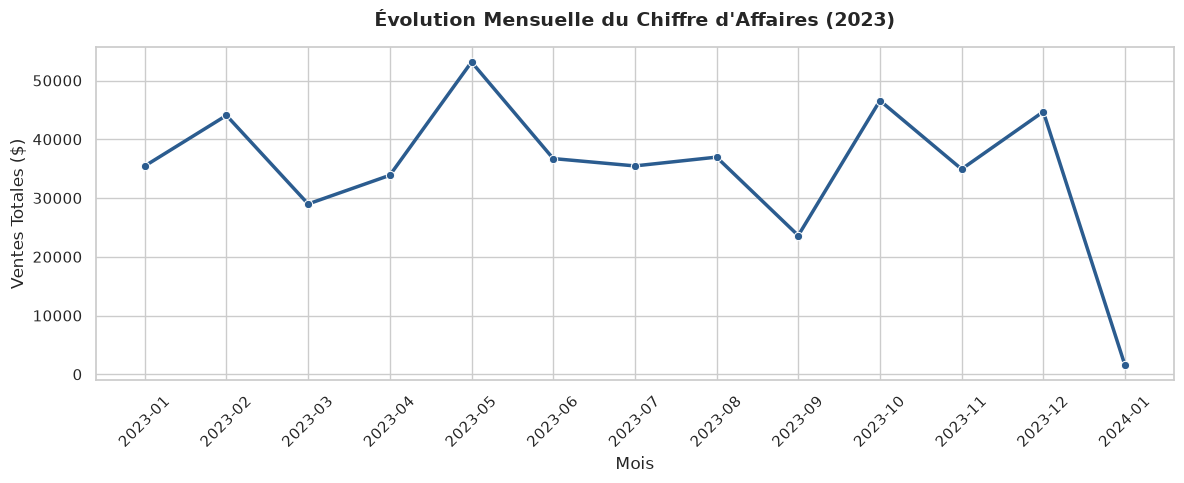

In [10]:
plt.figure(figsize=(12, 5))

# Groupement par mois
evol_ventes = df.groupby('Mois_Annee')['Total Amount'].sum().reset_index()
evol_ventes['Mois_Annee'] = evol_ventes['Mois_Annee'].astype(str)

# Tracé de la ligne
sns.lineplot(data=evol_ventes, x='Mois_Annee', y='Total Amount', marker='o', color='#2b5c8f', linewidth=2.5)

plt.title("Évolution Mensuelle du Chiffre d'Affaires (2023)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mois")
plt.ylabel("Ventes Totales ($)")
plt.xticks(rotation=45)
plt.tight_layout()

# Sauvegarde pour GitHub
plt.savefig('visuals/evolution_ventes.png', dpi=300)
plt.show()

## Graphique B : Répartition des ventes par Catégorie de Produit et par Genre

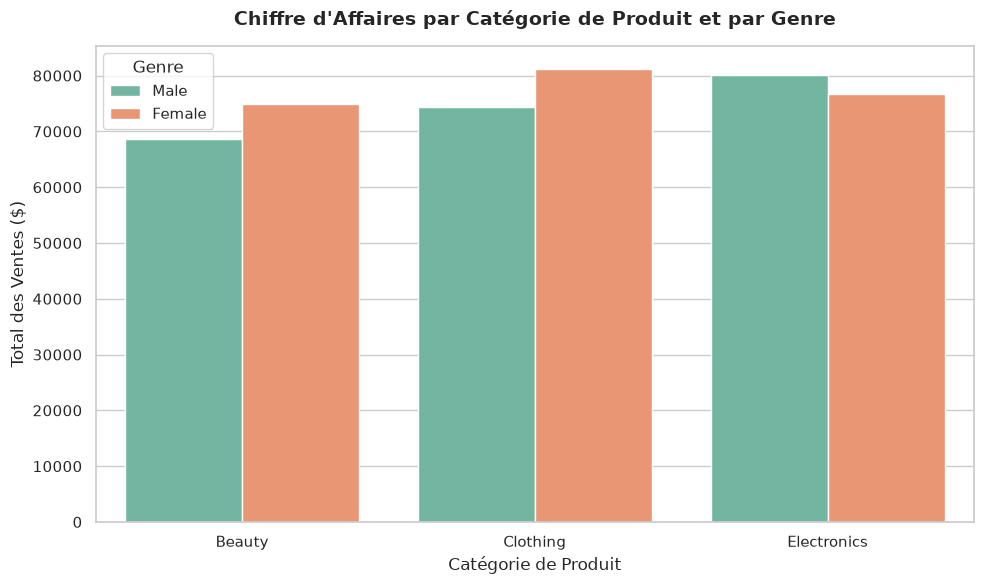

In [11]:
plt.figure(figsize=(10, 6))

# Graphique à barres croisé avec le Genre (Gender)
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender', estimator=sum, errorbar=None, palette='Set2')

plt.title("Chiffre d'Affaires par Catégorie de Produit et par Genre", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Catégorie de Produit")
plt.ylabel("Total des Ventes ($)")
plt.legend(title="Genre")
plt.tight_layout()

# Sauvegarde pour GitHub
plt.savefig('visuals/ventes_par_categorie_genre.png', dpi=300)
plt.show()

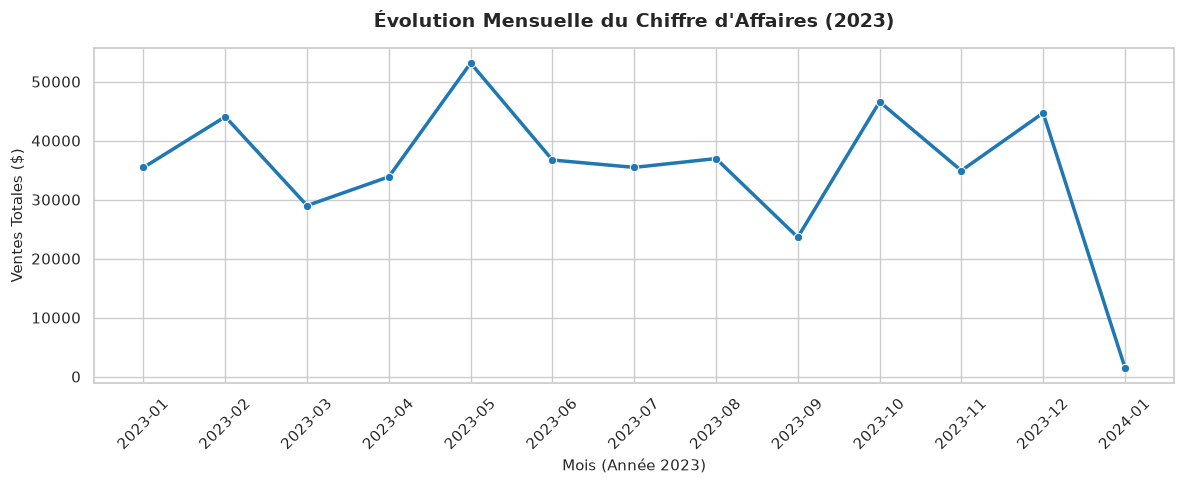

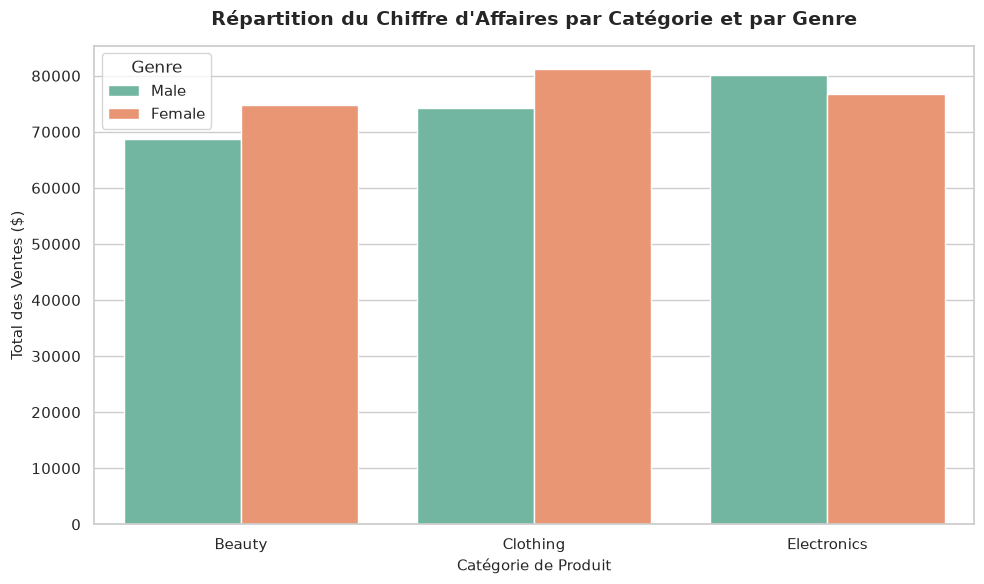

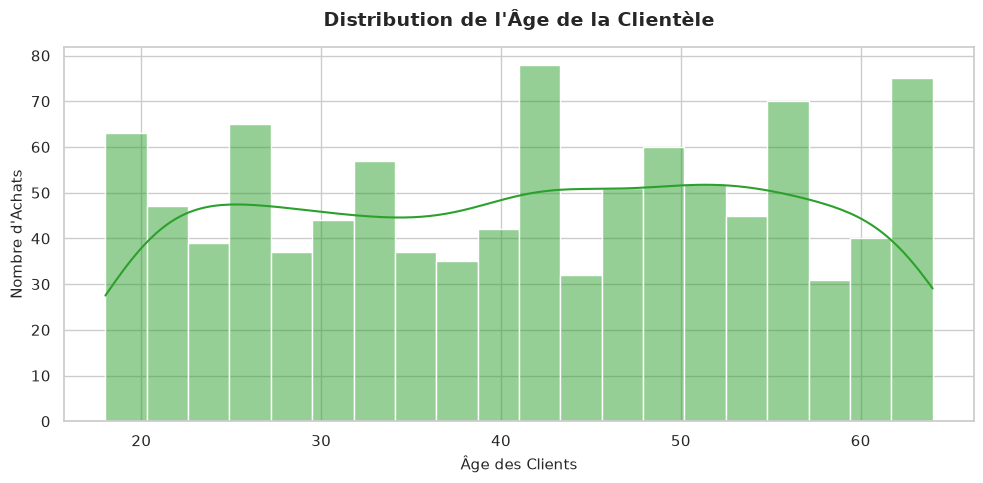

In [12]:
import os

# 0. S'assurer que le dossier pour GitHub existe
os.makedirs('visuals', exist_ok=True)

# On configure un style propre pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# GRAPH_A : Évolution mensuelle du Chiffre d'Affaires
# ==========================================
plt.figure(figsize=(12, 5))

# Groupement par mois (nécessite que la colonne 'Date' soit convertie)
df['Mois_Annee'] = df['Date'].dt.to_period('M')
evol_ventes = df.groupby('Mois_Annee')['Total Amount'].sum().reset_index()
evol_ventes['Mois_Annee'] = evol_ventes['Mois_Annee'].astype(str)

# Création de la courbe
sns.lineplot(
    data=evol_ventes, 
    x='Mois_Annee', 
    y='Total Amount', 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5
)

plt.title("Évolution Mensuelle du Chiffre d'Affaires (2023)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mois (Année 2023)", fontsize=11)
plt.ylabel("Ventes Totales ($)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

# Sauvegarde de l'image pour ton GitHub
plt.savefig('visuals/01_evolution_ventes.png', dpi=300)
plt.show()


# ==========================================
# GRAPH_B : Ventes par Catégorie et par Genre
# ==========================================
plt.figure(figsize=(10, 6))

# Graphique à barres croisé (Produit vs Genre)
sns.barplot(
    data=df, 
    x='Product Category', 
    y='Total Amount', 
    hue='Gender', 
    estimator=sum, 
    errorbar=None, 
    palette='Set2'
)

plt.title("Répartition du Chiffre d'Affaires par Catégorie et par Genre", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Catégorie de Produit", fontsize=11)
plt.ylabel("Total des Ventes ($)", fontsize=11)
plt.legend(title="Genre")
plt.tight_layout()

# Sauvegarde de l'image
plt.savefig('visuals/02_ventes_par_categorie_genre.png', dpi=300)
plt.show()


# ==========================================
# GRAPH_C (Bonus Portfolio) : Distribution des Âges des Clients
# ==========================================
plt.figure(figsize=(10, 5))

# Un histogramme avec une courbe de densité pour montrer la structure de la clientèle
sns.histplot(data=df, x='Age', kde=True, color='#2ca02c', bins=20)

plt.title("Distribution de l'Âge de la Clientèle", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Âge des Clients", fontsize=11)
plt.ylabel("Nombre d'Achats", fontsize=11)
plt.tight_layout()

# Sauvegarde de l'image
plt.savefig('visuals/03_distribution_age.png', dpi=300)
plt.show()